# Grad-CAM Gallery - Attention Per Trained Model

Side-by-side Grad-CAM for every trained checkpoint in `models`.

In [5]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

from src.data.dataset import MammogramDataset
from src.data.preprocessing import preprocess
from src.evaluation.gradcam import TARGET_LAYERS, compute_gradcam
from src.evaluation.gradcam_roi import energy_pointing_game, pointing_game
from src.models import build_model

MODELS_DIR = Path("../models")
IMAGE_ROOT = Path("../data/cbis-ddsm/cbis_ddsm")
VAL_CSV = Path("../data/cbis-ddsm/training/val.csv")

REGISTRY = {
    "baseline": ("baseline", "baseline"),
    # "regularised": ("deeper", "deeper"),
    "vgg16_scratch": ("vgg16", "vgg16"),
    "vgg16_imagenet": ("vgg16", "vgg16"),
}

available = [(p.stem, *REGISTRY[p.stem])
             for p in sorted(MODELS_DIR.glob("*.pt")) if p.stem in REGISTRY]
print(f"Trained checkpoints found ({len(available)}):")
for run_name, mname, lkey in available:
    print(f"{run_name:20s} -> build_model({mname!r}), layer {TARGET_LAYERS[lkey]}")

Trained checkpoints found (3):
baseline             -> build_model('baseline'), layer features.2.0
vgg16_imagenet       -> build_model('vgg16'), layer backbone.features.28
vgg16_scratch        -> build_model('vgg16'), layer backbone.features.28


## Grand Truth against Malignant validation cases with lesion ROI

In [6]:
N_CASES = 3

ds = MammogramDataset(VAL_CSV, IMAGE_ROOT, transform=None)
mal = [i for i in range(len(ds.df)) if int(ds.df.iloc[i]["label"]) == 1]

samples = []
for i in mal:
    roi = ds.load_roi(i, (224, 224))
    if roi is None or roi.sum() == 0:
        continue
    image_id = str(ds.df.iloc[i]["image_id"])
    img = preprocess(IMAGE_ROOT / f"{image_id}.dcm", image_size=224, use_clahe=True)
    samples.append((i, img, roi))
    if len(samples) >= N_CASES:
        break

print(f"Selected {len(samples)} malignant cases with ROIs: {[s[0] for s in samples]}")

Selected 3 malignant cases with ROIs: [0, 1, 2]


## Compute Grad-CAM for each model

In [7]:
results = {}
for run_name, mname, lkey in available:
    try:
        model = build_model(mname, pretrained=False)
        model.load_state_dict(
            torch.load(MODELS_DIR / f"{run_name}.pt", map_location="cpu"))
        model.eval()
    except Exception as exc:                       # noqa: BLE001
        print(f"[skip] {run_name}: {type(exc).__name__}: {exc}")
        continue

    layer = TARGET_LAYERS[lkey]
    per_case = []
    for _, img, roi in samples:
        t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0)
        cam = compute_gradcam(model, t, target_layer_name=layer)
        per_case.append((cam, energy_pointing_game(cam, roi), pointing_game(cam, roi)))
    results[run_name] = per_case

    del model
    torch.cuda.empty_cache()
    print(f"[done] {run_name}")

[done] baseline
[done] vgg16_imagenet
[done] vgg16_scratch


## Gallery

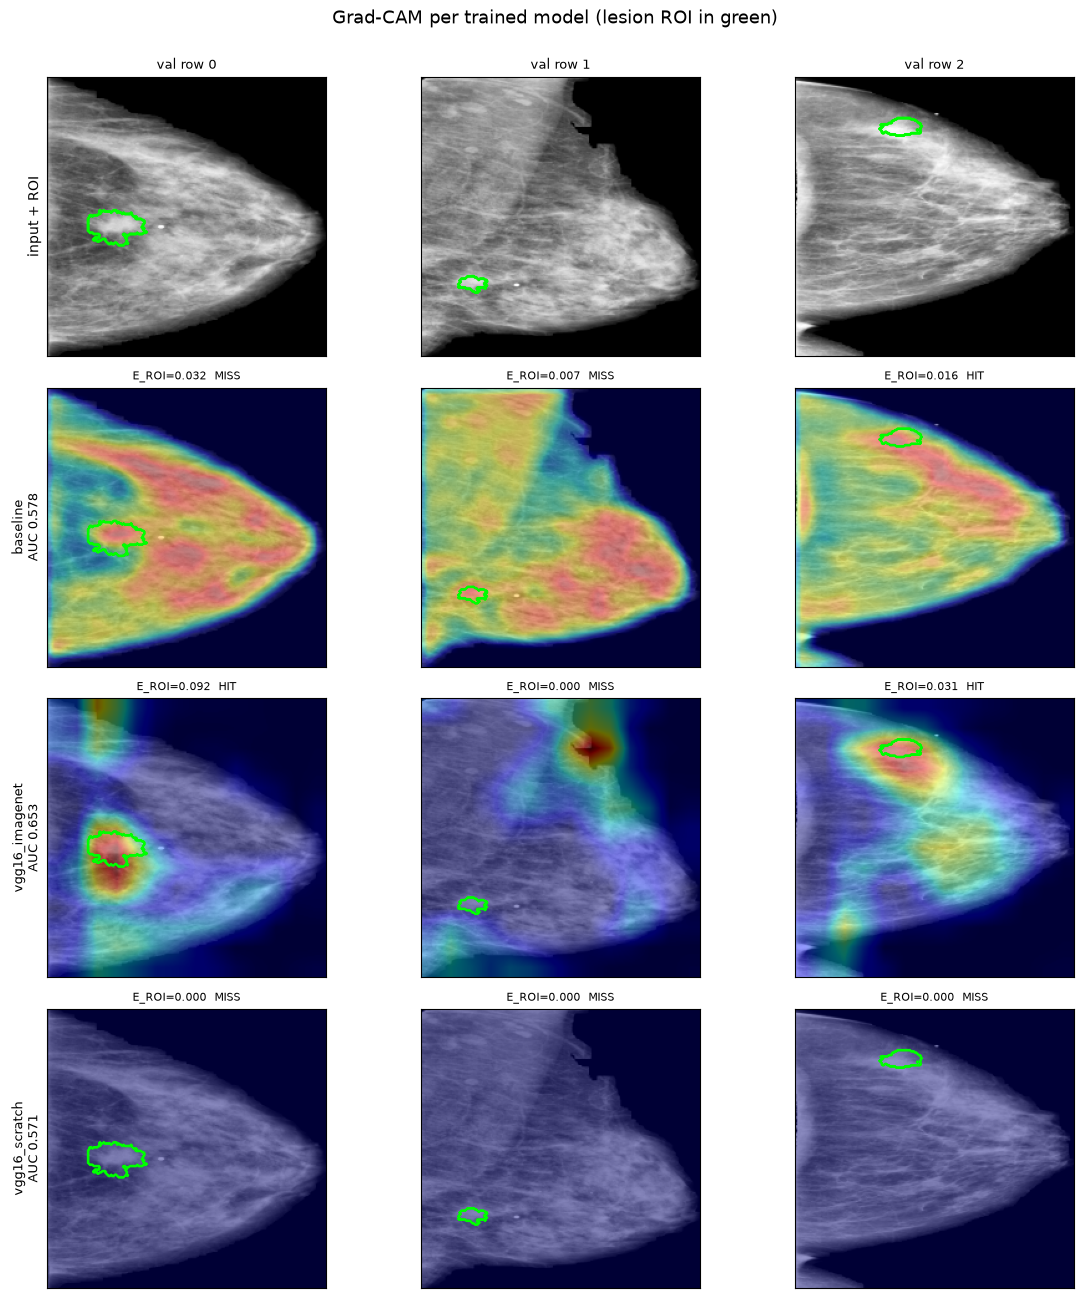

In [8]:
auc = {}
mpath = Path("../results/metrics.json")
if mpath.exists():
    for r in json.loads(mpath.read_text()).get("runs", []):
        auc[r.get("model")] = r.get("test", {}).get("auc")

model_names = list(results)
n_rows, n_cols = 1 + len(model_names), len(samples)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 3.3 * n_rows), squeeze=False)

def _strip(ax):
    ax.set_xticks([]); ax.set_yticks([])

# Reference row: input + lesion ROI
for c, (idx, img, roi) in enumerate(samples):
    ax = axes[0][c]
    ax.imshow(img, cmap="gray")
    ax.contour(roi, colors="lime", linewidths=1.2)
    ax.set_title(f"val row {idx}", fontsize=9)
    _strip(ax)
axes[0][0].set_ylabel("input + ROI", fontsize=10)

# One row per model
for r, run_name in enumerate(model_names, start=1):
    for c, (idx, img, roi) in enumerate(samples):
        cam, energy, hit = results[run_name][c]
        ax = axes[r][c]
        ax.imshow(img, cmap="gray")
        ax.imshow(cam, cmap="jet", alpha=0.42)
        ax.contour(roi, colors="lime", linewidths=1.0)
        ax.set_title(f"E_ROI={energy:.3f}  {'HIT' if hit else 'MISS'}", fontsize=8)
        _strip(ax)
    label = run_name + (f"\nAUC {auc[run_name]:.3f}" if auc.get(run_name) else "")
    axes[r][0].set_ylabel(label, fontsize=9)

fig.suptitle("Grad-CAM per trained model (lesion ROI in green)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()